**cnn**

In [1]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to class directories (to be filled by user)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # Assumes images are in PNG format
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anti_covid, y_anti_covid = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_non_antiviral, y_random_non_antiviral = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anti_covid, X_random_non_antiviral), axis=0)
y = np.concatenate((y_anti_covid, y_random_non_antiviral), axis=0)

# Shuffle and split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

def build_cnn_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(256, (3, 3), activation='relu'),  # Additional layer
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, 
        decay_steps=5000, 
        decay_rate=0.9, 
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

# Instantiate model
model = build_cnn_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_cnn_model.keras", 
    monitor='val_accuracy', 
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train, 
    batch_size=32, 
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_cnn_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_cnn_model.keras")
print("Model saved successfully in /kaggle/working/")

2025-05-25 12:34:34.708277: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748176474.889227      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748176474.943722      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1748176496.683077      35 gpu_device.cc:2022] Created device /job:localhost/repl

Epoch 1/200


I0000 00:00:1748176501.472109      97 service.cc:148] XLA service 0x7ca6e0010ef0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748176501.472792      97 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176501.472815      97 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1748176501.922207      97 cuda_dnn.cc:529] Loaded cuDNN version 90300


10/17 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6826 - loss: 4.7129

I0000 00:00:1748176505.657748      97 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/17 ━━━━━━━━━━━━━━━━━━━━ 12s 316ms/step - accuracy: 0.7347 - loss: 4.1008 - val_accuracy: 0.8308 - val_loss: 1.2448
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8252 - loss: 1.0675 - val_accuracy: 0.8308 - val_loss: 0.6732
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8364 - loss: 0.6104 - val_accuracy: 0.8308 - val_loss: 0.5361
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8194 - loss: 0.5527 - val_accuracy: 0.8308 - val_loss: 0.5047
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8482 - loss: 0.4747 - val_accuracy: 0.8308 - val_loss: 0.4696
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8265 - loss: 0.4950 - val_accuracy: 0.8308 - val_loss: 0.4668
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8496 - loss: 0.4431 - val_accuracy: 0.8308 - val_loss: 0.5134
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8174 - loss: 0.5658 - val_accuracy: 0.8308 - val

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step


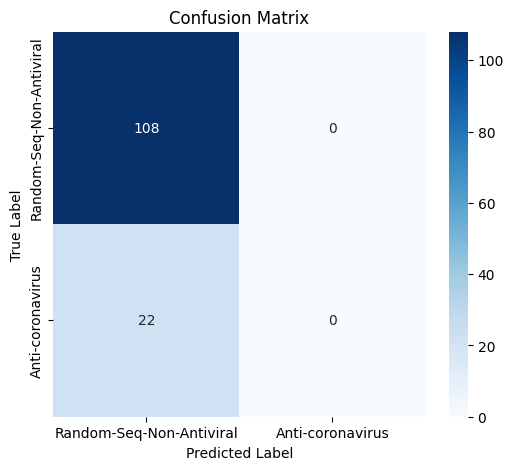


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.83      1.00      0.91       108
        Anti-coronavirus       0.00      0.00      0.00        22

                accuracy                           0.83       130
               macro avg       0.42      0.50      0.45       130
            weighted avg       0.69      0.83      0.75       130



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


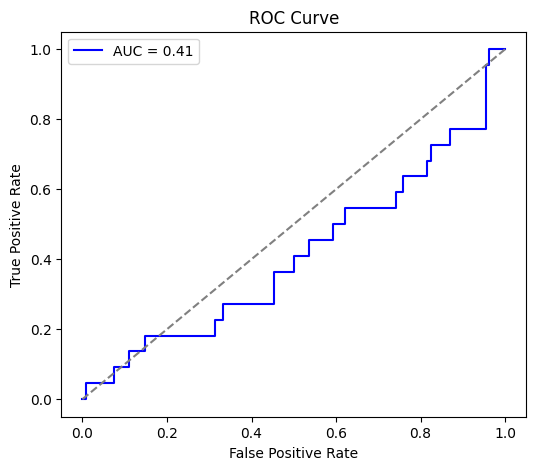

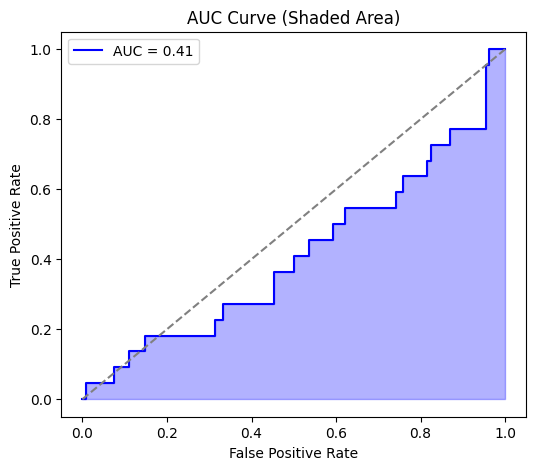

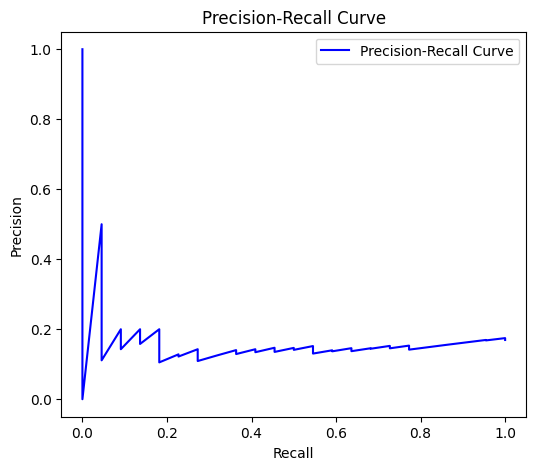

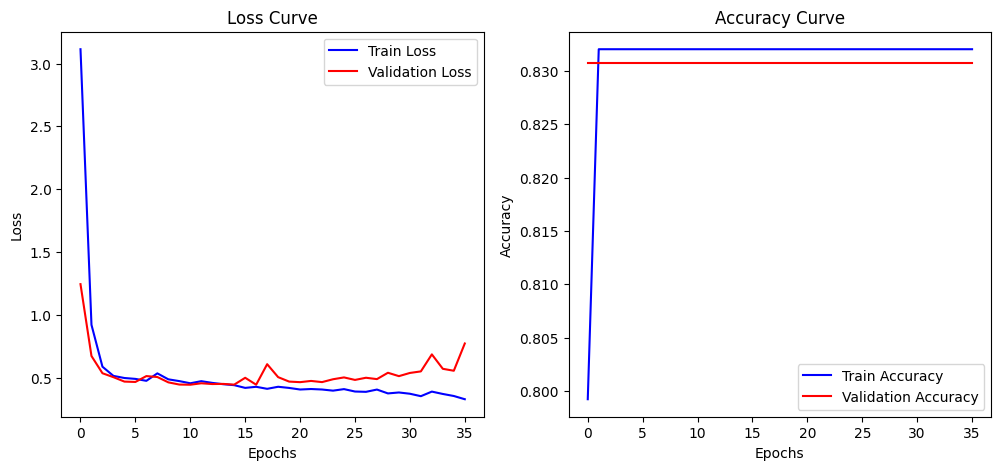

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5/5 ━━━━━━━━

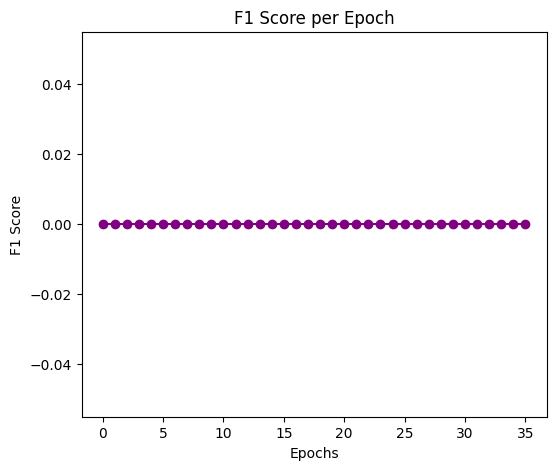

Cohen’s Kappa Score: 0.00
Matthews Correlation Coefficient (MCC): 0.00


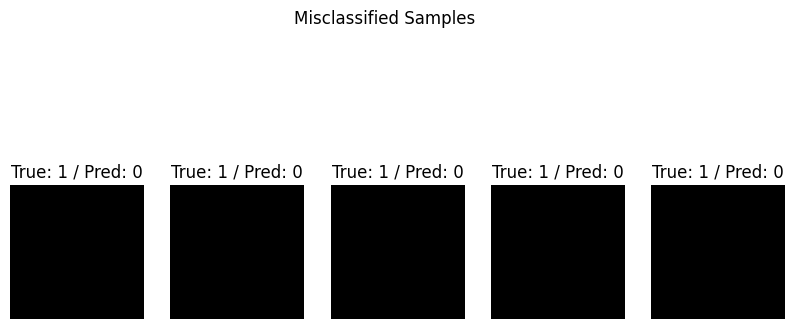


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8308
Precision 0.0000
   Recall 0.0000
 F1-score 0.0000
      AUC 0.4120
      MCC 0.0000
   G-mean 0.0000


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn+SE**

In [3]:
import os
import numpy as np
from glob import glob
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128  

# Paths to Ennavia D dataset directories (to be filled by user)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 
# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  # PNG images
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anticorona, y_anticorona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_nonantiviral, y_random_nonantiviral = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anticorona, X_random_nonantiviral), axis=0)
y = np.concatenate((y_anticorona, y_random_nonantiviral), axis=0)

# Split into train and test (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Shuffle training data
train_indices = np.arange(X_train.shape[0])
np.random.shuffle(train_indices)
X_train, y_train = X_train[train_indices], y_train[train_indices]

# Shuffle test data
test_indices = np.arange(X_test.shape[0])
np.random.shuffle(test_indices)
X_test, y_test = X_test[test_indices], y_test[test_indices]

# Squeeze and Excitation Block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.multiply([input_tensor, se])

# Define CNN Model with SE Attention
def build_se_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with Residual Connection and SE
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.Add()([x, res])
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = squeeze_excite_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Pooling and Dense Layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # Optimizer with LR scheduler
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, 
        decay_steps=5000, 
        decay_rate=0.9, 
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Build model
model = build_se_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_se_cnn.keras", 
    monitor='val_accuracy', 
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train, 
    batch_size=32, 
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best model and evaluate
model.load_weights("best_se_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_cnn+SE_model.keras")
print("Model saved successfully in /kaggle/working/")

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 30s 756ms/step - accuracy: 0.7622 - loss: 3.7048 - val_accuracy: 0.3923 - val_loss: 3.0976
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8267 - loss: 2.6312 - val_accuracy: 0.1692 - val_loss: 2.3488
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8124 - loss: 1.8850 - val_accuracy: 0.1692 - val_loss: 1.8435
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8397 - loss: 1.2900 - val_accuracy: 0.1692 - val_loss: 1.4935
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8423 - loss: 0.9592 - val_accuracy: 0.1692 - val_loss: 1.2046
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8385 - loss: 0.7471 - val_accuracy: 0.1692 - val_loss: 1.0720
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8450 - loss: 0.6146 - val_accuracy: 0.1692 - val_loss: 0.9785
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8332 - loss: 0.5129 - val_accuracy: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step


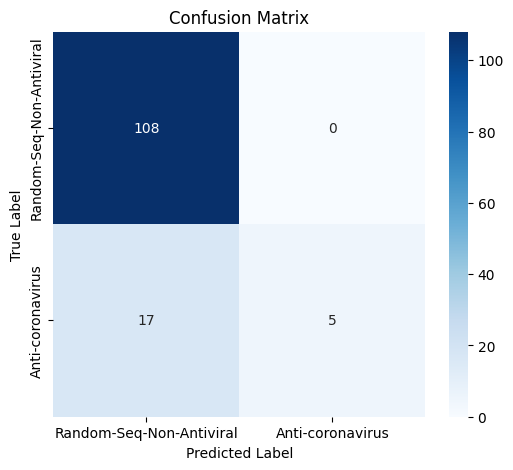


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.86      1.00      0.93       108
        Anti-coronavirus       1.00      0.23      0.37        22

                accuracy                           0.87       130
               macro avg       0.93      0.61      0.65       130
            weighted avg       0.89      0.87      0.83       130



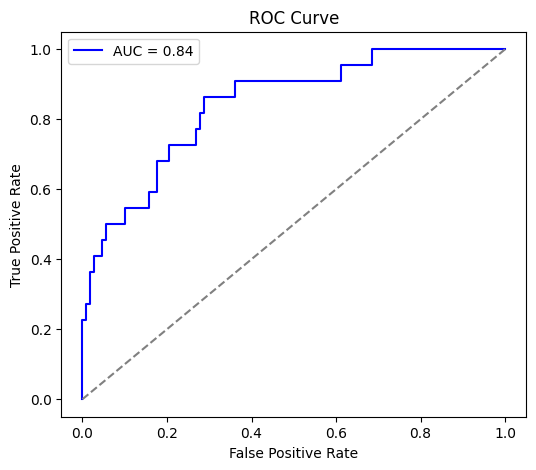

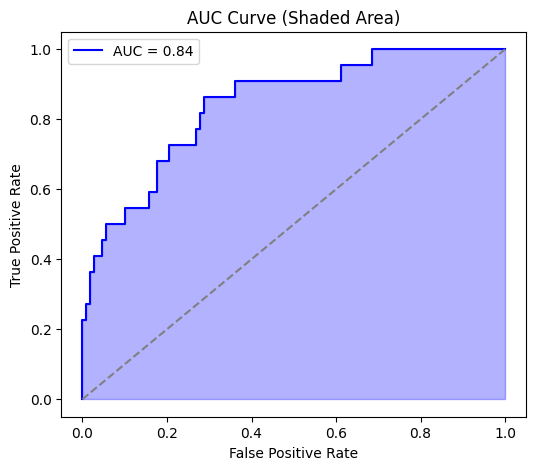

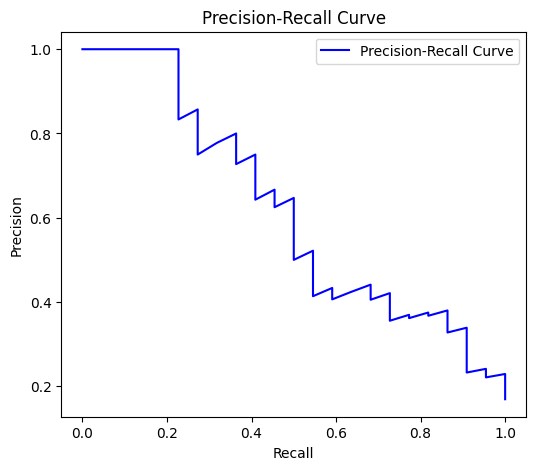

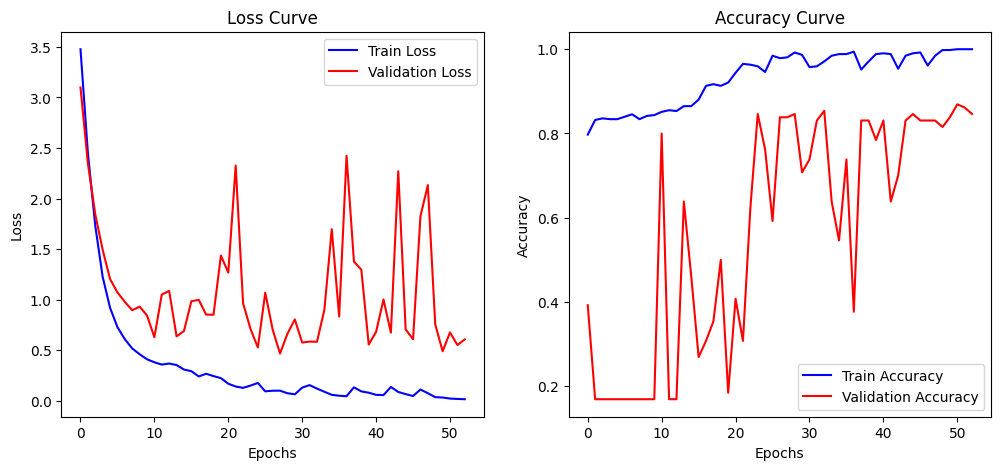

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
5/5 ━━━━━━━━

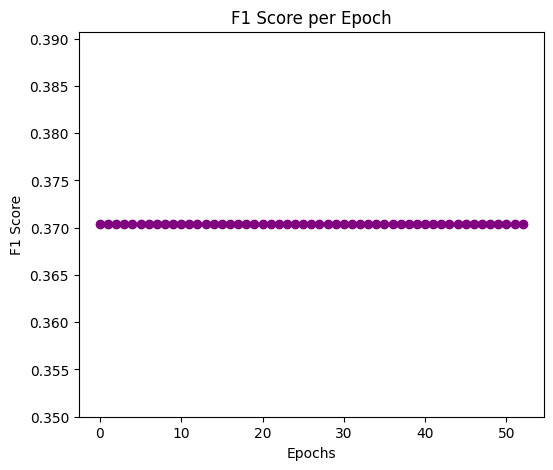

Cohen’s Kappa Score: 0.33
Matthews Correlation Coefficient (MCC): 0.44


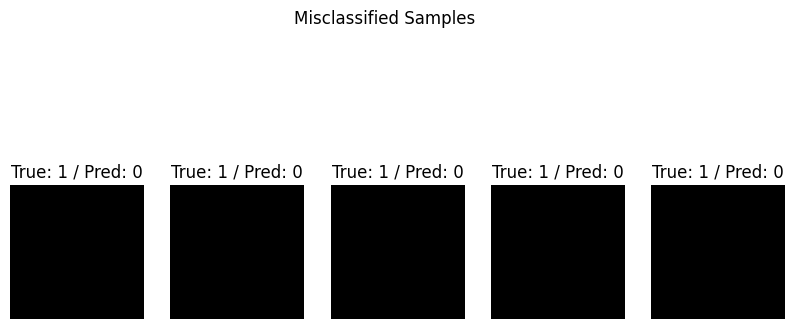


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8692
Precision 1.0000
   Recall 0.2273
 F1-score 0.3704
      AUC 0.8418
      MCC 0.4431
   G-mean 0.4767


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**cnn + CBAM**

In [5]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, regularizers

# Paths to directories (Leave empty to be filled by user)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 128, 128

# Load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load images from both classes
X_anticorona, y_anticorona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_nonantiviral, y_random_nonantiviral = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anticorona, X_random_nonantiviral), axis=0)
y = np.concatenate((y_anticorona, y_random_nonantiviral), axis=0)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

# Shuffle train
indices_train = np.arange(X_train.shape[0])
np.random.shuffle(indices_train)
X_train, y_train = X_train[indices_train], y_train[indices_train]

# Shuffle test
indices_test = np.arange(X_test.shape[0])
np.random.shuffle(indices_test)
X_test, y_test = X_test[indices_test], y_test[indices_test]

# CBAM Attention Module
def cbam_block(input_tensor, reduction_ratio=16):
    filters = input_tensor.shape[-1]

    # Channel attention
    avg_pool = layers.GlobalAveragePooling2D()(input_tensor)
    max_pool = layers.GlobalMaxPooling2D()(input_tensor)

    shared_dense = layers.Dense(filters // reduction_ratio, activation="relu")
    avg_out = shared_dense(avg_pool)
    max_out = shared_dense(max_pool)

    shared_dense_2 = layers.Dense(filters, activation="sigmoid")
    avg_out = shared_dense_2(avg_out)
    max_out = shared_dense_2(max_out)

    avg_out = layers.Reshape((1, 1, filters))(avg_out)
    max_out = layers.Reshape((1, 1, filters))(max_out)

    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)

    x = layers.Multiply()([input_tensor, channel_attention])

    # Spatial attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)
    spatial_attention = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(spatial_attention)

    output_tensor = layers.Multiply()([x, spatial_attention])
    return output_tensor

# Define CNN + CBAM model
def build_cbam_cnn(input_shape):
    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2
    x = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 with residual connection
    res = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.Add()([x, res])
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = cbam_block(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Global average pooling and dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    # Learning rate schedule
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001, 
        decay_steps=5000, 
        decay_rate=0.9, 
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate model
model = build_cbam_cnn((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_cbam_cnn.keras", 
    monitor='val_accuracy', 
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train, 
    batch_size=32, 
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best weights and evaluate
model.load_weights("best_cbam_cnn.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save final model
tf.keras.models.save_model(model, "/kaggle/working/final_cbam_cnn_model.keras")
print("Model saved to /kaggle/working/")

Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 32s 800ms/step - accuracy: 0.7717 - loss: 3.6833 - val_accuracy: 0.1692 - val_loss: 3.0129
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8520 - loss: 2.4816 - val_accuracy: 0.1692 - val_loss: 2.2006
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8167 - loss: 1.7172 - val_accuracy: 0.1692 - val_loss: 1.6790
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8311 - loss: 1.1858 - val_accuracy: 0.1692 - val_loss: 1.3064
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8498 - loss: 0.8233 - val_accuracy: 0.1692 - val_loss: 1.0786
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8217 - loss: 0.6613 - val_accuracy: 0.1692 - val_loss: 0.9715
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8607 - loss: 0.5118 - val_accuracy: 0.1692 - val_loss: 0.8974
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8335 - loss: 0.4550 - val_accuracy: 

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 463ms/step


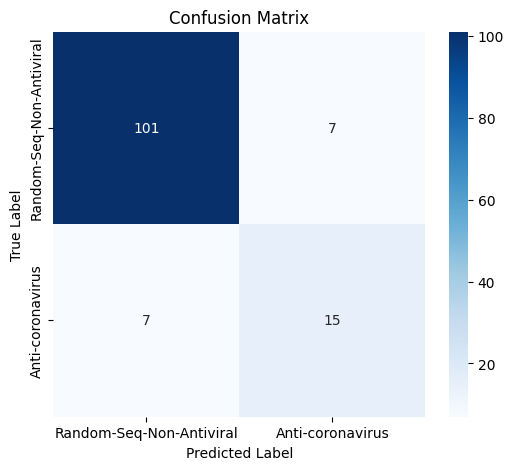


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.94      0.94      0.94       108
        Anti-coronavirus       0.68      0.68      0.68        22

                accuracy                           0.89       130
               macro avg       0.81      0.81      0.81       130
            weighted avg       0.89      0.89      0.89       130



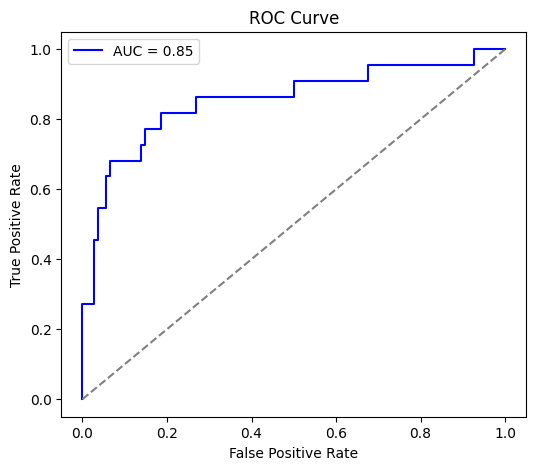

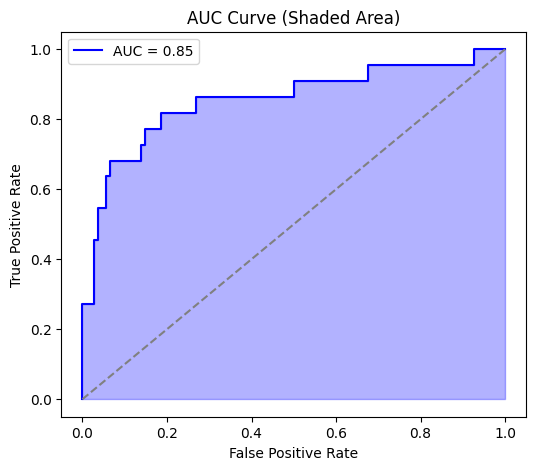

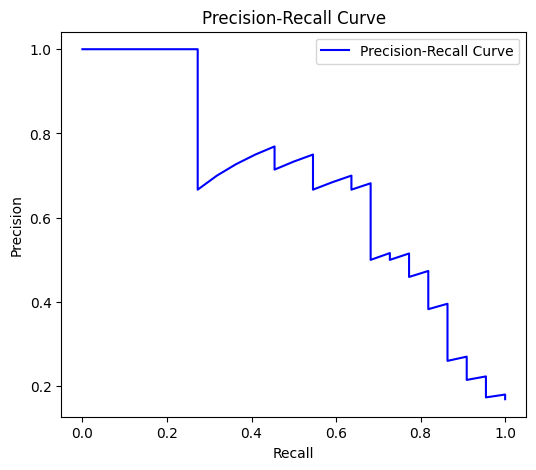

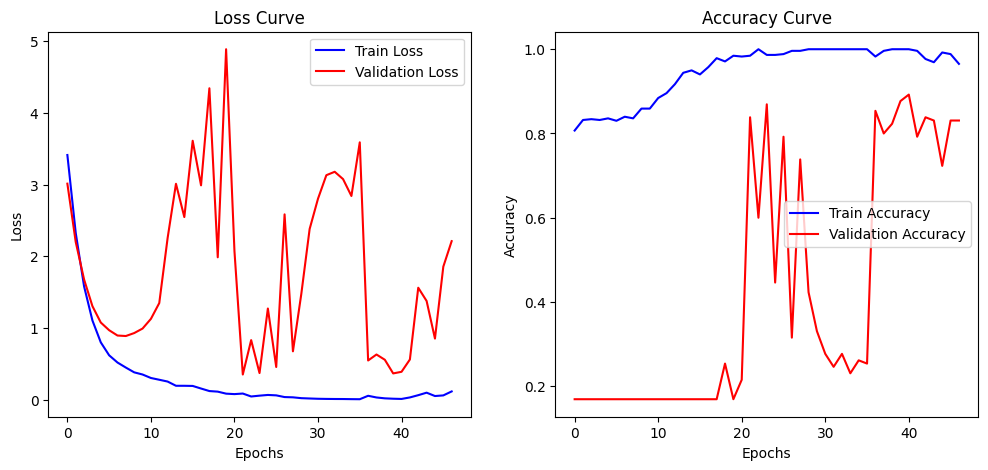

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
5/5 ━━━━━━━━

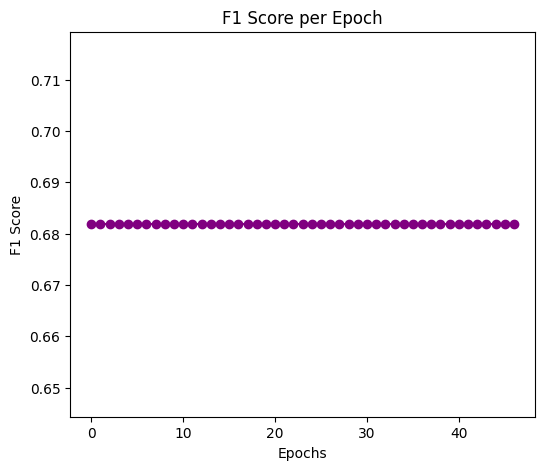

Cohen’s Kappa Score: 0.62
Matthews Correlation Coefficient (MCC): 0.62


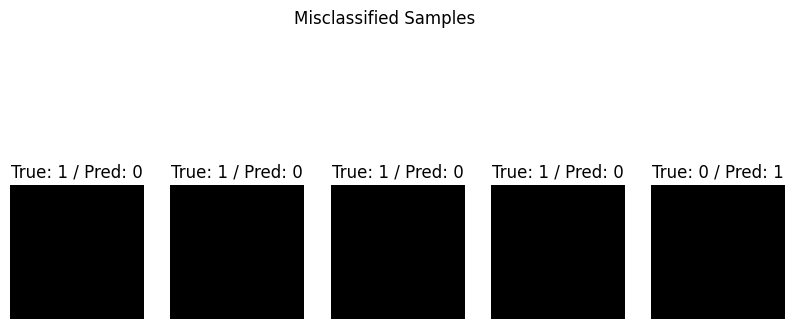


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.8923
Precision 0.6818
   Recall 0.6818
 F1-score 0.6818
      AUC 0.8544
      MCC 0.6170
   G-mean 0.7985


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50**

In [7]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Set image dimensions
IMG_HEIGHT, IMG_WIDTH = 224, 224

# Dataset directories (✅ Corrected variable name)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0  # Normalize to [0,1]
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# ✅ Load both classes (corrected variable name used)
X_anticoronavirus, y_anticoronavirus = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non_antiviral, y_non_antiviral = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine data
X = np.concatenate((X_anticoronavirus, X_non_antiviral), axis=0)
y = np.concatenate((y_anticoronavirus, y_non_antiviral), axis=0)

# Shuffle and split into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Build ResNet50-based model
def build_resnet_model(input_shape):
    base_model = applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    for layer in base_model.layers[:140]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001,
        decay_steps=5000,
        decay_rate=0.9,
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate model
model = build_resnet_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_resnet_model.keras",
    monitor='val_accuracy',
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Load best weights and evaluate
model.load_weights("best_resnet_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

# Save final model
tf.keras.models.save_model(model, "/kaggle/working/final_resnet50_model.keras")
print("Model saved successfully in /kaggle/working/")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5613 - loss: 5.4236 - val_accuracy: 0.8308 - val_loss: 4.9005
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 184ms/step - accuracy: 0.5726 - loss: 5.1822 - val_accuracy: 0.8308 - val_loss: 4.8055
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 188ms/step - accuracy: 0.6020 - loss: 5.1218 - val_accuracy: 0.8308 - val_loss: 4.7114
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step - accuracy: 0.6685 - loss: 4.9359 - val_accuracy: 0.8308 - val_loss: 4.6200
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.7331 - loss: 4.8961 - val_accuracy: 0.8308 - val_loss: 4.5404
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 194ms/step - accuracy: 0.6953 - loss: 4.6736 - val_accuracy: 0.8308 - val_loss: 4.4559
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.7559 - loss: 4.4907 - val_accuracy: 0.8308 - val_loss: 4.3884
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


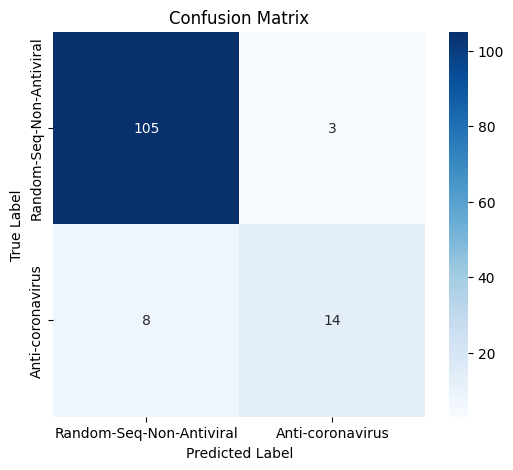


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.93      0.97      0.95       108
        Anti-coronavirus       0.82      0.64      0.72        22

                accuracy                           0.92       130
               macro avg       0.88      0.80      0.83       130
            weighted avg       0.91      0.92      0.91       130



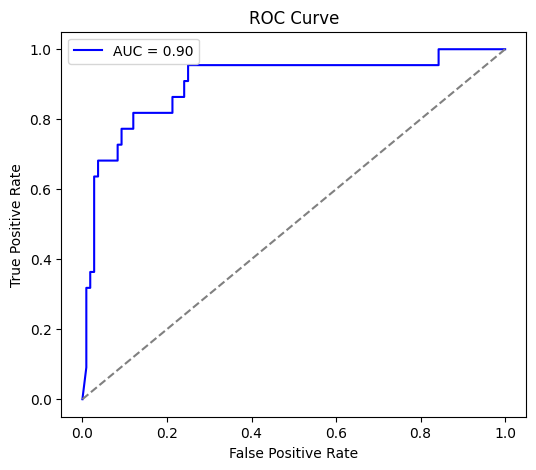

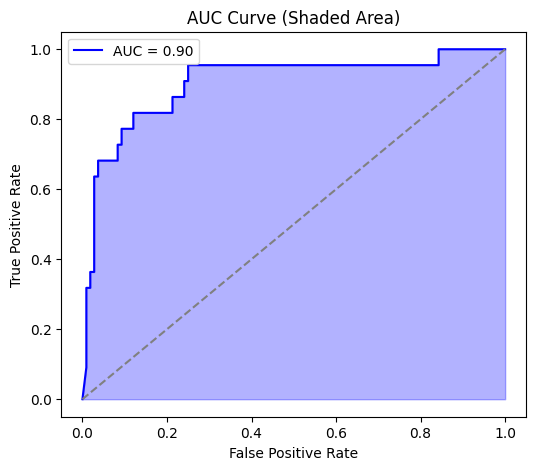

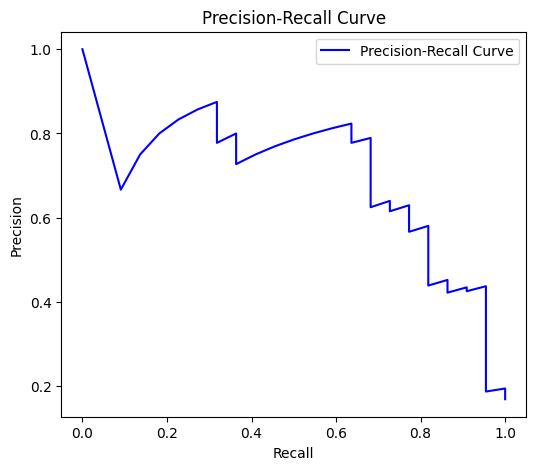

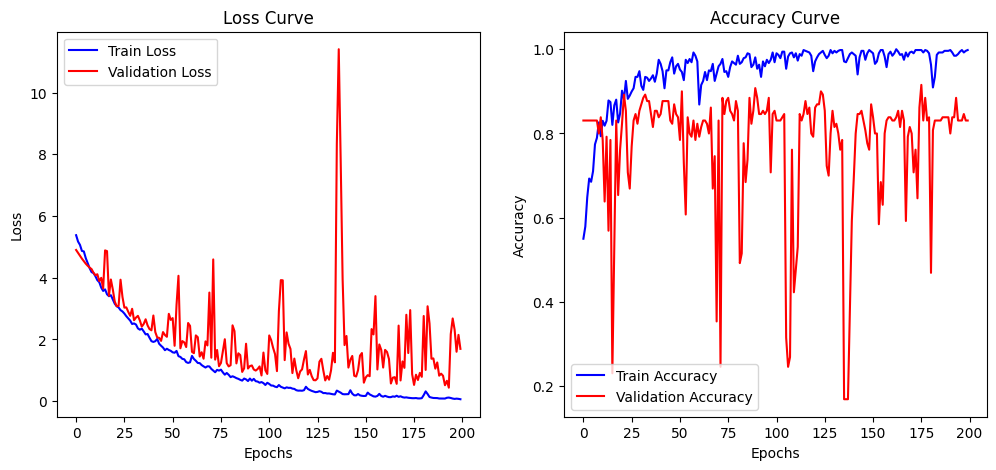

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━

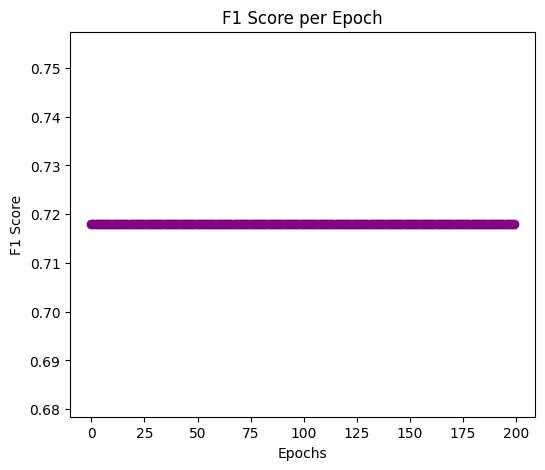

Cohen’s Kappa Score: 0.67
Matthews Correlation Coefficient (MCC): 0.68


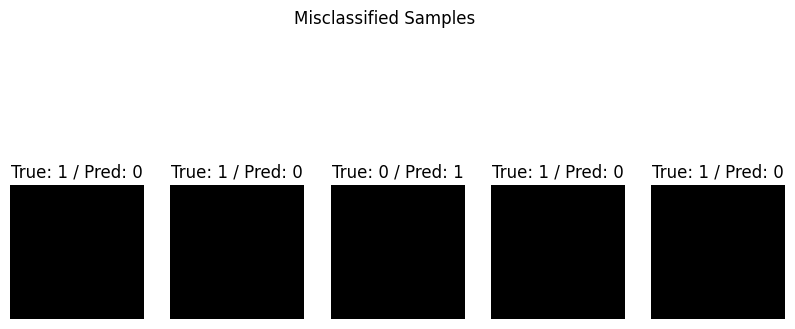


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9154
Precision 0.8235
   Recall 0.6364
 F1-score 0.7179
      AUC 0.9036
      MCC 0.6768
   G-mean 0.7866


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet 50 + SE**

In [9]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models, callbacks, applications, regularizers

# Image dimensions for ResNet50
IMG_HEIGHT, IMG_WIDTH = 224, 224  

# Paths to the two Ennavia D class directories (🔁 Fill these)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Function to load & preprocess all images in a directory
def load_images_from_directory(directory, label):
    images, labels = [], []
    for file in glob(os.path.join(directory, "*.png")):
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img.astype("float32") / 255.0
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load both classes
X_anti, y_anti = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_non, y_non = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine and split (80% train / 20% test)
X = np.concatenate([X_anti, X_non], axis=0)
y = np.concatenate([y_anti, y_non], axis=0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Squeeze-and-Excitation block
def squeeze_excite_block(input_tensor, ratio=16):
    filters = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(filters // ratio, activation="relu")(se)
    se = layers.Dense(filters, activation="sigmoid")(se)
    se = layers.Reshape((1, 1, filters))(se)
    return layers.Multiply()([input_tensor, se])

# Build ResNet50 + SE model
def build_resnet_se(input_shape):
    base = applications.ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )
    # Freeze early layers
    for layer in base.layers[:140]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = squeeze_excite_block(x)                     # SE block after backbone
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu",
                    kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=1e-4,
        decay_steps=5000,
        decay_rate=0.9,
        staircase=True
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Instantiate and train
model = build_resnet_se((IMG_HEIGHT, IMG_WIDTH, 3))

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True
)
checkpoint = callbacks.ModelCheckpoint(
    "best_resnet_se.keras", monitor="val_accuracy", save_best_only=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=32,
    epochs=200,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Evaluate and save
model.load_weights("best_resnet_se.keras")
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc * 100:.2f}%")

model.save("/kaggle/working/final_resnet50_se_model.keras", include_optimizer=False)
print("Model saved to /kaggle/working/final_resnet50_se_model.keras")


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5305 - loss: 5.4617 - val_accuracy: 0.1692 - val_loss: 5.3929
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.6397 - loss: 5.1044 - val_accuracy: 0.1692 - val_loss: 5.1912
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.6393 - loss: 5.0382 - val_accuracy: 0.1692 - val_loss: 4.9931
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.7447 - loss: 4.7472 - val_accuracy: 0.1769 - val_loss: 4.8215
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 278ms/step - accuracy: 0.7321 - loss: 4.6621 - val_accuracy: 0.8385 - val_loss: 4.6325
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.8030 - loss: 4.4327 - val_accuracy: 0.8308 - val_loss: 4.4779
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.7416 - loss: 4.4265 - val_accuracy: 0.8308 - val_loss: 4.3217
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/step - accuracy: 0.7841 - loss: 4.2413 - val_accura

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


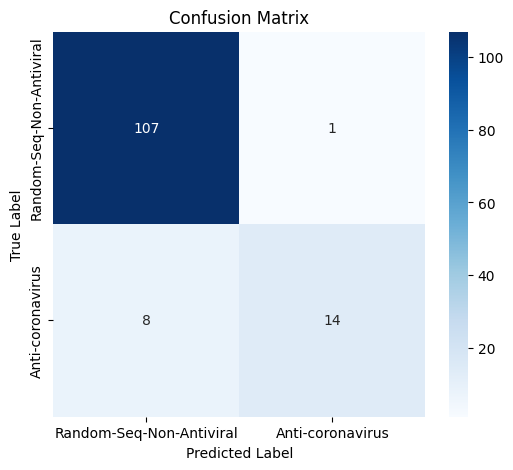


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.93      0.99      0.96       108
        Anti-coronavirus       0.93      0.64      0.76        22

                accuracy                           0.93       130
               macro avg       0.93      0.81      0.86       130
            weighted avg       0.93      0.93      0.93       130



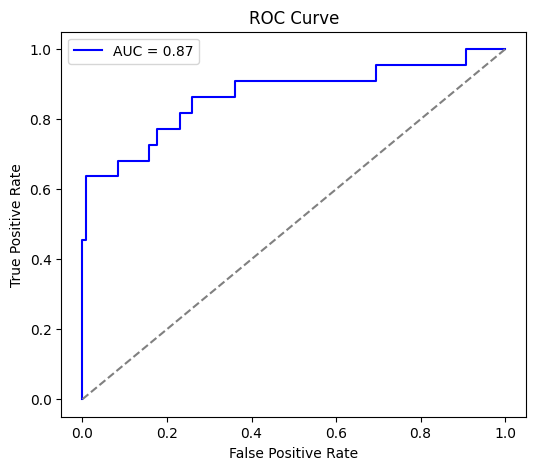

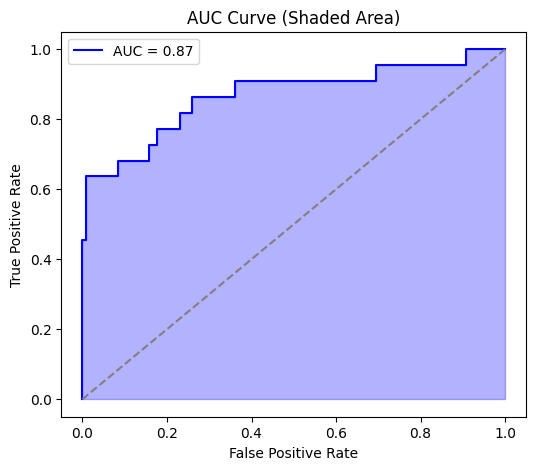

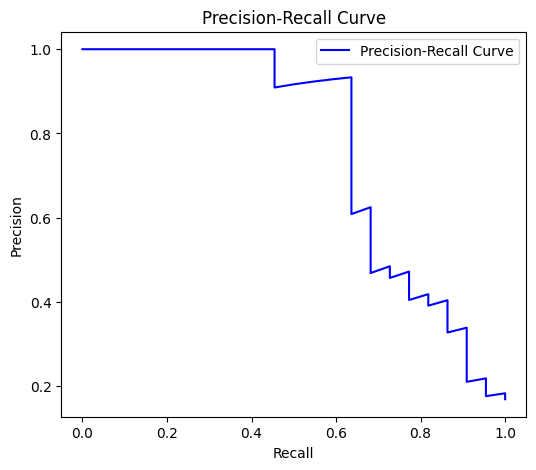

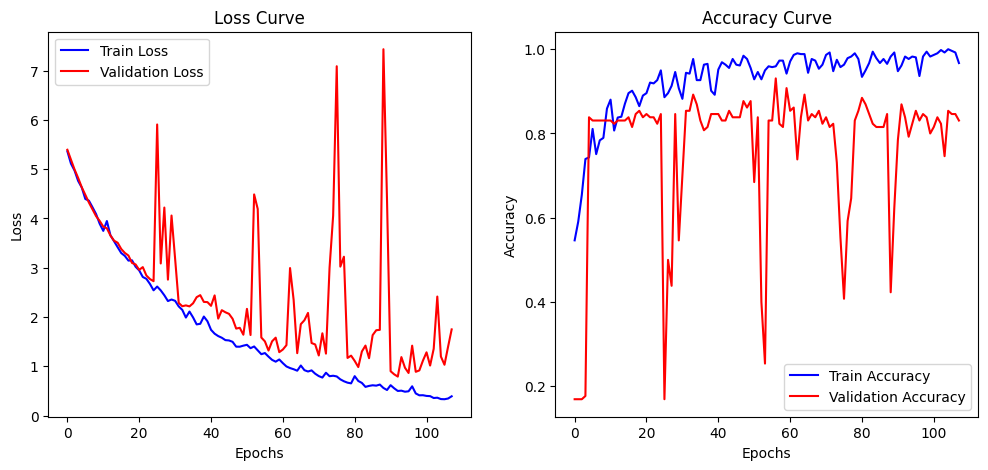

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━

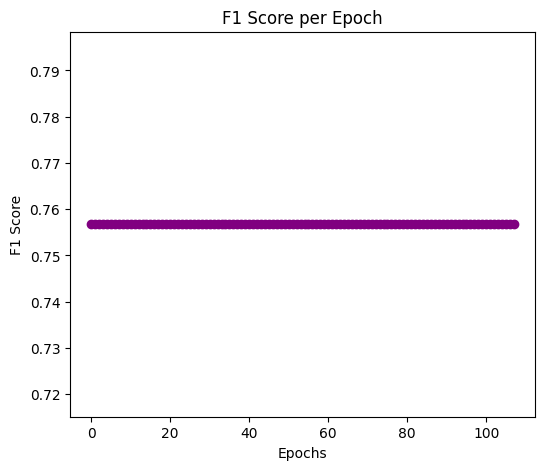

Cohen’s Kappa Score: 0.72
Matthews Correlation Coefficient (MCC): 0.74


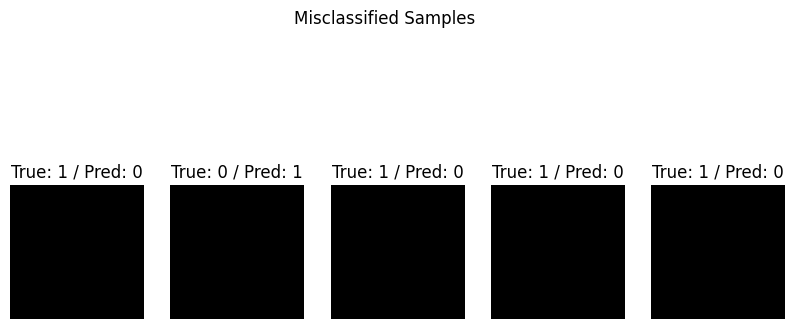


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9308
Precision 0.9333
   Recall 0.6364
 F1-score 0.7568
      AUC 0.8678
      MCC 0.7360
   G-mean 0.7940


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**resnet50 +CBAM**

In [11]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D, Dense, Reshape, Multiply,
    Conv2D, Add, Activation, Lambda, Dropout
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split

# Paths to directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions and parameters
IMG_HEIGHT, IMG_WIDTH = 224, 224
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Function to load and preprocess images for a given class
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_seq, y_random_seq = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine both classes into a single dataset
X = np.concatenate((X_anti_corona, X_random_seq), axis=0)
y = np.concatenate((y_anti_corona, y_random_seq), axis=0)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Shuffle training dataset
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data Augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
)

# CBAM Attention Mechanism
def cbam_block(input_tensor, ratio=8):
    channel_avg = GlobalAveragePooling2D()(input_tensor)
    channel_max = GlobalMaxPooling2D()(input_tensor)

    shared_dense_1 = Dense(input_tensor.shape[-1] // ratio, activation='relu')
    shared_dense_2 = Dense(input_tensor.shape[-1], activation='sigmoid')

    channel_avg = shared_dense_1(channel_avg)
    channel_avg = shared_dense_2(channel_avg)

    channel_max = shared_dense_1(channel_max)
    channel_max = shared_dense_2(channel_max)

    channel_att = Add()([channel_avg, channel_max])
    channel_att = Activation('sigmoid')(channel_att)
    channel_att = Reshape((1, 1, input_tensor.shape[-1]))(channel_att)
    channel_refined = Multiply()([input_tensor, channel_att])

    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(channel_refined)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(channel_refined)
    concat = Add()([avg_pool, max_pool])

    spatial_att = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    spatial_refined = Multiply()([channel_refined, spatial_att])

    return spatial_refined

# Define ResNet50-based Model with CBAM
def build_resnet_cbam_model(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze early layers
    for layer in base_model.layers[:143]:
        layer.trainable = False
    for layer in base_model.layers[143:]:
        layer.trainable = True

    x = cbam_block(base_model.output)

    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = Dropout(0.5)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    initial_learning_rate = 0.0001
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate model
model = build_resnet_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_resnet_cbam_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate and save
model.load_weights("best_resnet_cbam_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

tf.keras.models.save_model(model, "/kaggle/working/final_resnet50+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.7791 - loss: 8.6052 - val_accuracy: 0.8308 - val_loss: 8.1708
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.8528 - loss: 8.0291 - val_accuracy: 0.8308 - val_loss: 7.7305
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.8598 - loss: 7.4859 - val_accuracy: 0.8308 - val_loss: 7.3268
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 268ms/step - accuracy: 0.8781 - loss: 7.0484 - val_accuracy: 0.8538 - val_loss: 6.7978
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.8878 - loss: 6.5646 - val_accuracy: 0.8308 - val_loss: 6.4453
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step - accuracy: 0.9216 - loss: 6.0976 - val_accuracy: 0.8538 - val_loss: 6.0275
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 275ms/step - accuracy: 0.9514 - loss: 5.6685 - val_accuracy: 0.8769 - val_loss: 5.6329
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step - accuracy: 0.9441 - loss: 5.2805 - val_accura

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step


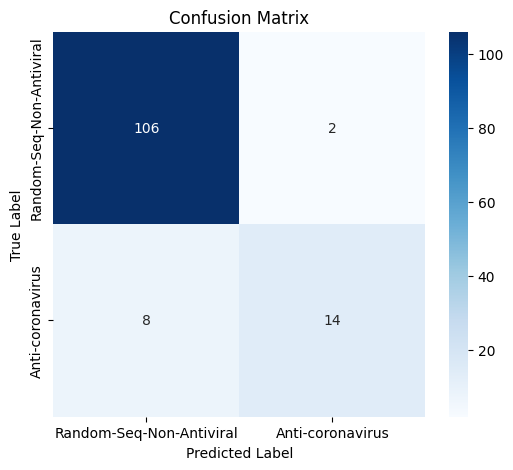


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.93      0.98      0.95       108
        Anti-coronavirus       0.88      0.64      0.74        22

                accuracy                           0.92       130
               macro avg       0.90      0.81      0.85       130
            weighted avg       0.92      0.92      0.92       130



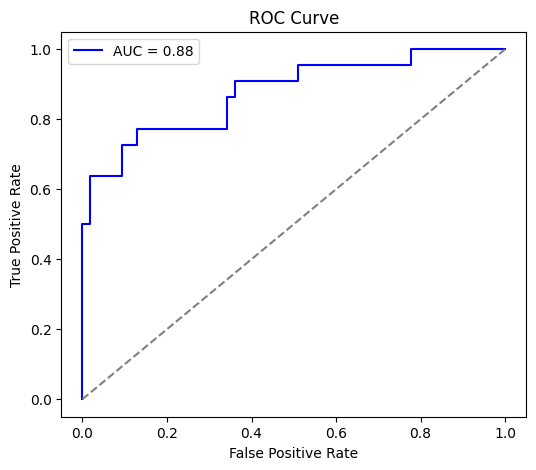

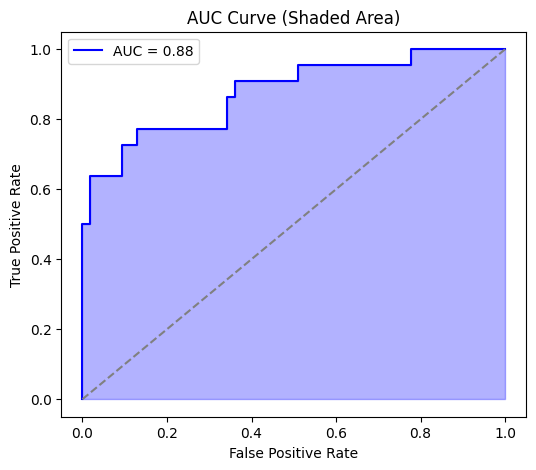

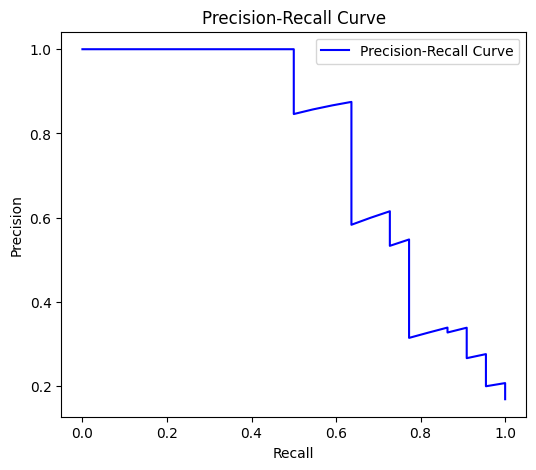

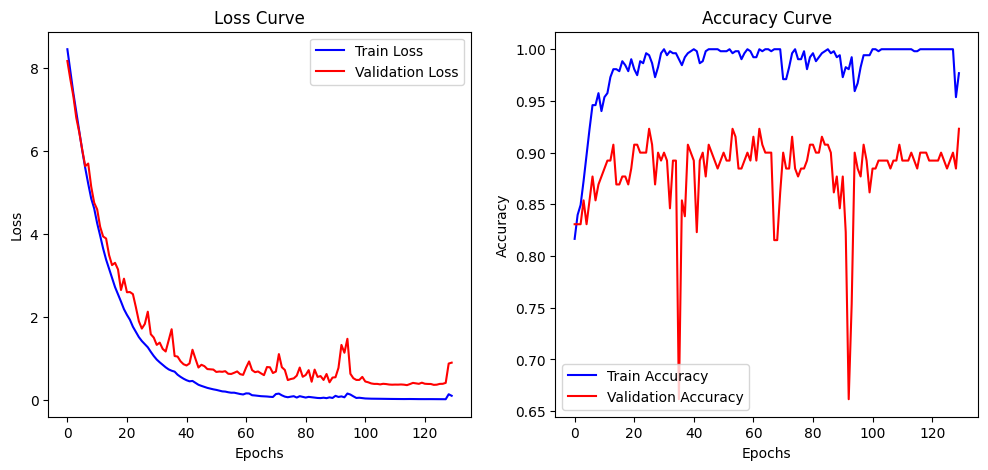

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
5/5 ━━━━━━━

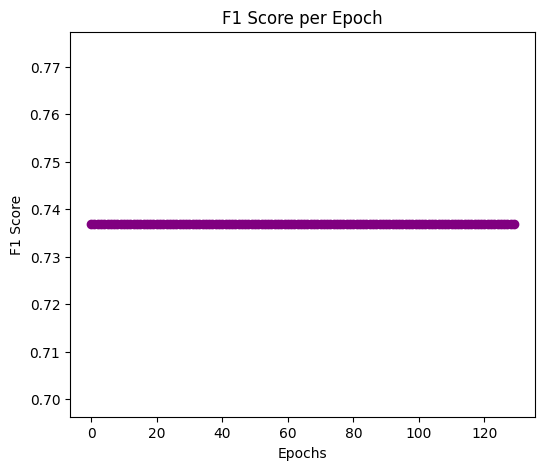

Cohen’s Kappa Score: 0.69
Matthews Correlation Coefficient (MCC): 0.71


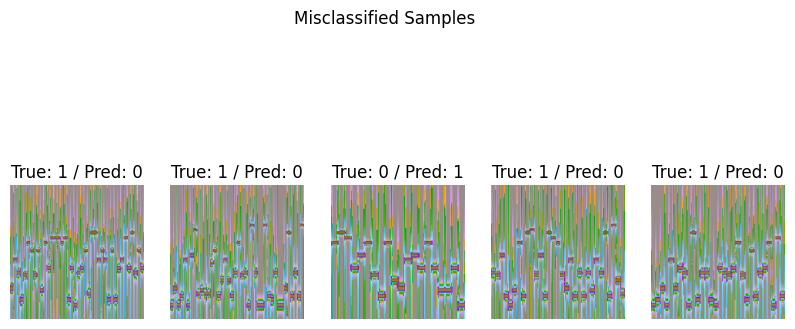


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9231
Precision 0.8750
   Recall 0.6364
 F1-score 0.7368
      AUC 0.8771
      MCC 0.7052
   G-mean 0.7903


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3**

In [13]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications, regularizers
from sklearn.model_selection import train_test_split

# Paths to directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions for InceptionV3
IMG_HEIGHT, IMG_WIDTH = 299, 299  
TEST_SIZE = 0.2  
RANDOM_STATE = 42  
BATCH_SIZE = 32

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))  
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))  
        img = img / 255.0  
        images.append(img)
        labels.append(label)  
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_coronavirus, y_anti_coronavirus = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_seq, y_random_seq = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_coronavirus, X_random_seq), axis=0)
y = np.concatenate((y_anti_coronavirus, y_random_seq), axis=0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE,
    stratify=y
)

# Shuffle training data
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Build InceptionV3 Model
def build_inception_model(input_shape):
    base_model = applications.InceptionV3(
        weights='imagenet', 
        include_top=False, 
        input_shape=input_shape
    )

    for layer in base_model.layers[:280]:  
        layer.trainable = False
    for layer in base_model.layers[280:]:
        layer.trainable = True

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)  

    model = models.Model(inputs, outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, 
        decay_steps=5000, 
        decay_rate=0.9, 
        staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

# Instantiate the model
model = build_inception_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)
model_checkpoint = callbacks.ModelCheckpoint(
    "best_inception_model.keras", 
    monitor='val_accuracy', 
    save_best_only=True
)

# Train model
history = model.fit(
    X_train, y_train, 
    batch_size=BATCH_SIZE, 
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate and save model
model.load_weights("best_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3_model.keras")
print("Model saved successfully in /kaggle/working/")


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.5733 - loss: 5.3578 - val_accuracy: 0.3692 - val_loss: 5.2016
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 270ms/step - accuracy: 0.6130 - loss: 5.1785 - val_accuracy: 0.4538 - val_loss: 5.1042
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 268ms/step - accuracy: 0.6815 - loss: 5.0116 - val_accuracy: 0.6923 - val_loss: 4.9218
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.7746 - loss: 4.8231 - val_accuracy: 0.5538 - val_loss: 4.9173
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step - accuracy: 0.7420 - loss: 4.7353 - val_accuracy: 0.6923 - val_loss: 4.7832
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 267ms/step - accuracy: 0.7595 - loss: 4.6388 - val_accuracy: 0.8615 - val_loss: 4.6199
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 263ms/step - accuracy: 0.7621 - loss: 4.5707 - val_accuracy: 0.8846 - val_loss: 4.5044
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 189ms/

5/5 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step 


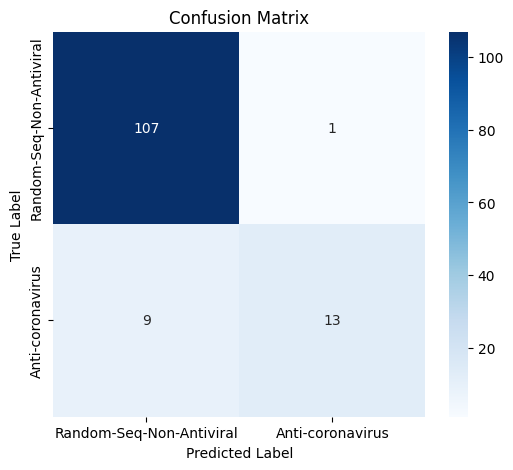


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.92      0.99      0.96       108
        Anti-coronavirus       0.93      0.59      0.72        22

                accuracy                           0.92       130
               macro avg       0.93      0.79      0.84       130
            weighted avg       0.92      0.92      0.92       130



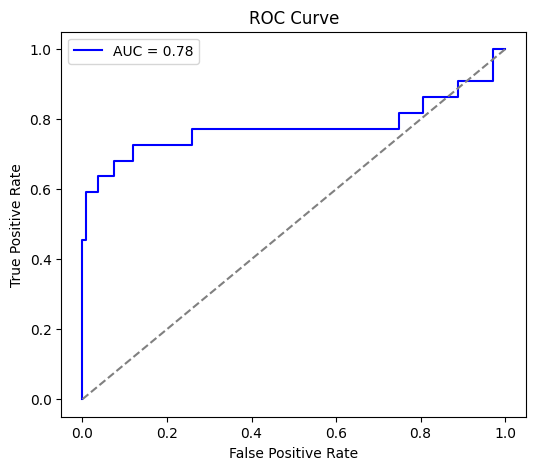

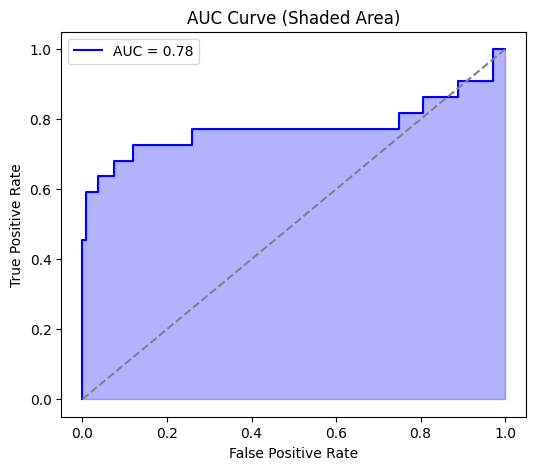

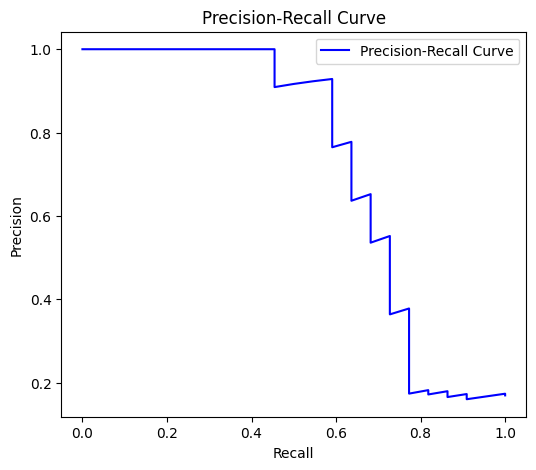

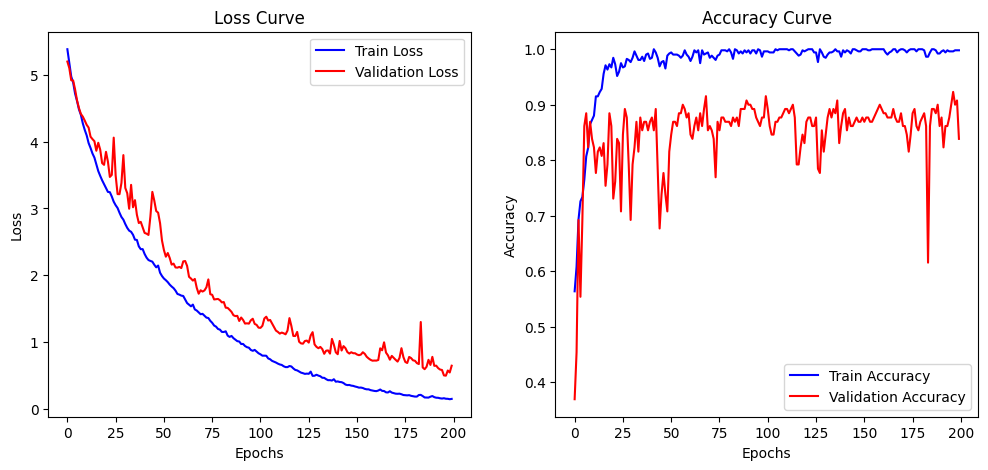

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 

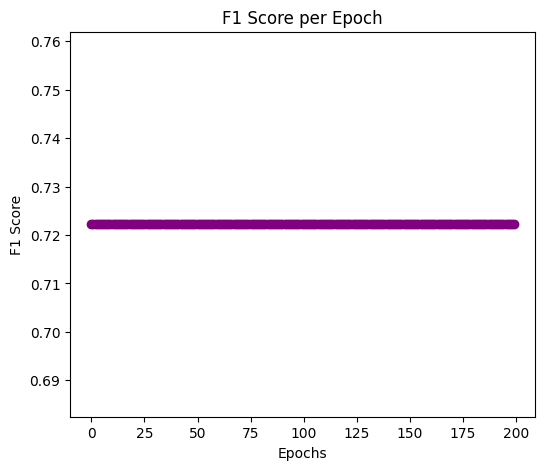

Cohen’s Kappa Score: 0.68
Matthews Correlation Coefficient (MCC): 0.70


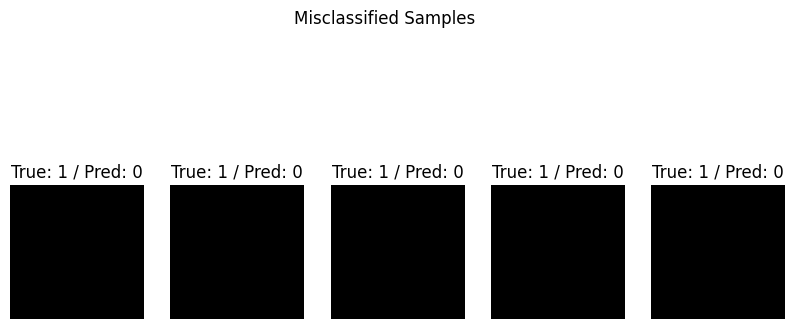


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9231
Precision 0.9286
   Recall 0.5909
 F1-score 0.7222
      AUC 0.7769
      MCC 0.7035
   G-mean 0.7651


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 + SE**

In [15]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split

# Paths to directories
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Function to load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets for both classes
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_seq, y_random_seq = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_corona, X_random_seq), axis=0)
y = np.concatenate((y_anti_corona, y_random_seq), axis=0)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Shuffle training data
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# Squeeze-and-Excitation (SE) Block
def se_block(input_tensor, ratio=16):
    channel = input_tensor.shape[-1]
    se = layers.GlobalAveragePooling2D()(input_tensor)
    se = layers.Dense(channel // ratio, activation='relu')(se)
    se = layers.Dense(channel, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channel))(se)
    return layers.Multiply()([input_tensor, se])

# Build InceptionV3 with SE Attention
def build_inception_se_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers[:249]:
        layer.trainable = False
    for layer in base_model.layers[249:]:
        layer.trainable = True

    x = se_block(base_model.output)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.9, staircase=True
    )
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    return model

# Instantiate model
model = build_inception_se_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_se_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train model
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate
model.load_weights("best_se_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with SE Attention: {test_accuracy * 100:.2f}%")

# Save model
tf.keras.models.save_model(model, "/kaggle/working/final_InceptionV3+SE_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4749 - loss: 9.1503 - val_accuracy: 0.1846 - val_loss: 8.7501
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 362ms/step - accuracy: 0.6179 - loss: 8.7204 - val_accuracy: 0.3923 - val_loss: 8.5166
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step - accuracy: 0.6207 - loss: 8.4420 - val_accuracy: 0.5923 - val_loss: 8.2847
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 266ms/step - accuracy: 0.6628 - loss: 8.1540 - val_accuracy: 0.5769 - val_loss: 8.0961
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 375ms/step - accuracy: 0.7305 - loss: 7.9156 - val_accuracy: 0.7846 - val_loss: 7.8458
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.7125 - loss: 7.7819 - val_accuracy: 0.7462 - val_loss: 7.6754
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 263ms/step - accuracy: 0.7226 - loss: 7.5453 - val_accuracy: 0.7231 - val_loss: 7.4810
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - accuracy: 0.7892 - loss: 7.2903 - val_accura

5/5 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step 


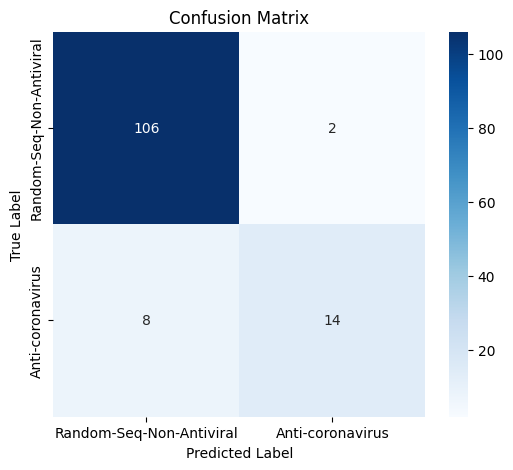


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.93      0.98      0.95       108
        Anti-coronavirus       0.88      0.64      0.74        22

                accuracy                           0.92       130
               macro avg       0.90      0.81      0.85       130
            weighted avg       0.92      0.92      0.92       130



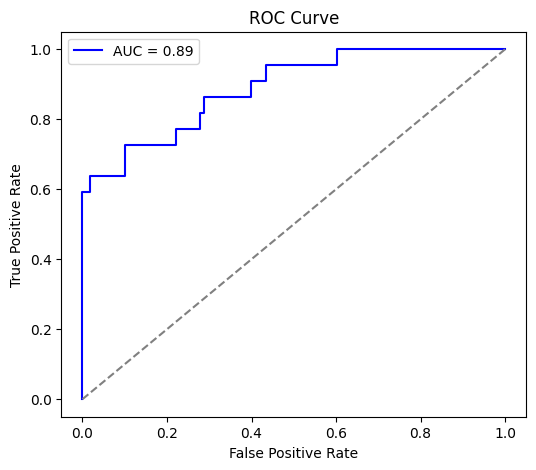

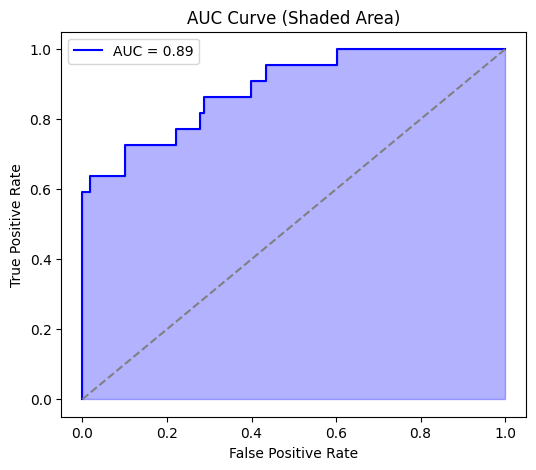

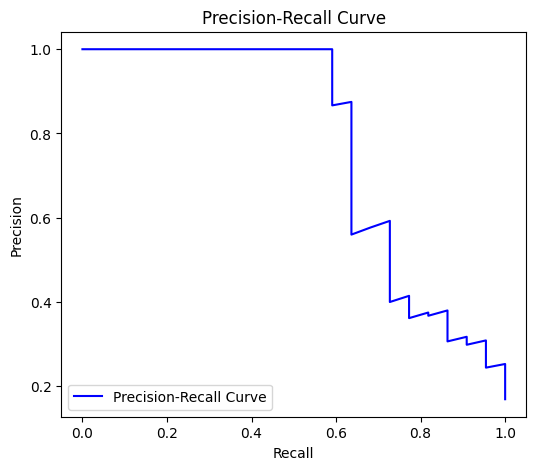

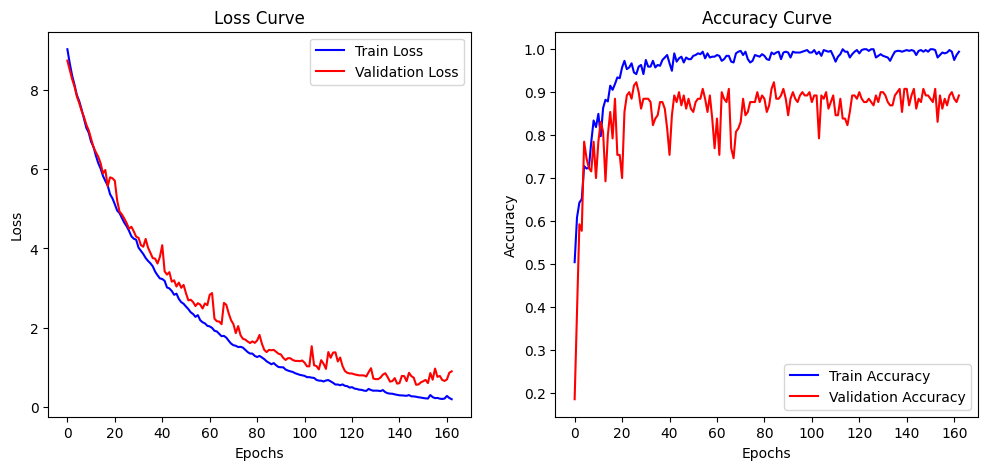

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 

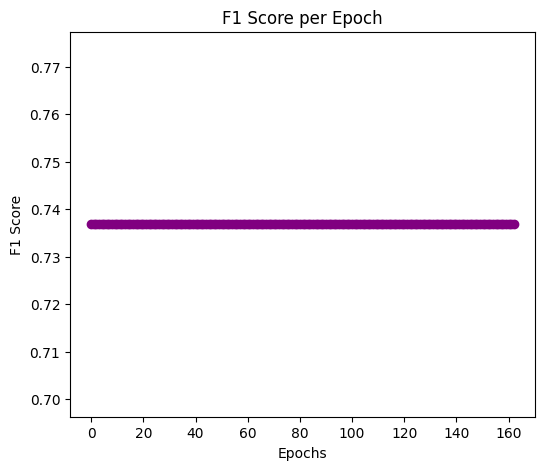

Cohen’s Kappa Score: 0.69
Matthews Correlation Coefficient (MCC): 0.71


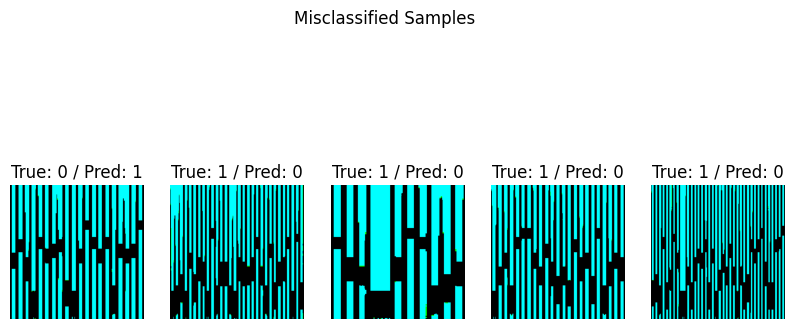


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9231
Precision 0.8750
   Recall 0.6364
 F1-score 0.7368
      AUC 0.8889
      MCC 0.7052
   G-mean 0.7903


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))


**inception v3 + CBAM**

In [17]:
import os
import numpy as np
from glob import glob
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from sklearn.model_selection import train_test_split

# Paths to directories (Update with your dataset paths)
data_dir_anti_coronavirus = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/anti-coronavirus images" 
data_dir_random_non_antiviral = "/kaggle/input/spectrogram-images-ennavia-d-mol-mass-based/spectrogram images/random-seq-non-antiviral images" 

# Image dimensions
IMG_HEIGHT, IMG_WIDTH = 299, 299  # For InceptionV3
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Load and preprocess images
def load_images_from_directory(directory, label):
    images, labels = [], []
    files = glob(os.path.join(directory, "*.png"))
    for file in files:
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = preprocess_input(img)
        images.append(img)
        labels.append(label)
    return np.array(images), np.array(labels)

# Load datasets
X_anti_corona, y_anti_corona = load_images_from_directory(data_dir_anti_coronavirus, label=1)
X_random_seq, y_random_seq = load_images_from_directory(data_dir_random_non_antiviral, label=0)

# Combine datasets
X = np.concatenate((X_anti_corona, X_random_seq), axis=0)
y = np.concatenate((y_anti_corona, y_random_seq), axis=0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Shuffle training set
indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)
X_train, y_train = X_train[indices], y_train[indices]

# Data augmentation
datagen = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

# CBAM block
def cbam_block(feature_map, ratio=8):
    # Channel Attention
    channel_avg = layers.GlobalAveragePooling2D()(feature_map)
    channel_max = layers.GlobalMaxPooling2D()(feature_map)
    channel = layers.Concatenate()([channel_avg, channel_max])
    channel = layers.Dense(feature_map.shape[-1] // ratio, activation='relu')(channel)
    channel = layers.Dense(feature_map.shape[-1], activation='sigmoid')(channel)
    channel = layers.Reshape((1, 1, feature_map.shape[-1]))(channel)
    feature_map = layers.Multiply()([feature_map, channel])

    # Spatial Attention
    avg_pool = layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(feature_map)
    max_pool = layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(feature_map)
    concat = layers.Concatenate(axis=-1)([avg_pool, max_pool])
    spatial = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    feature_map = layers.Multiply()([feature_map, spatial])

    return feature_map

# Build InceptionV3 + CBAM model
def build_inception_cbam_model(input_shape):
    base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base_model.layers[:249]:
        layer.trainable = False
    for layer in base_model.layers[249:]:
        layer.trainable = True

    x = cbam_block(base_model.output)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Compile model
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.0001, decay_steps=10000, decay_rate=0.9, staircase=True)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Instantiate model
model = build_inception_cbam_model((IMG_HEIGHT, IMG_WIDTH, 3))

# Callbacks
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint("best_cbam_inception_model.keras", monitor='val_accuracy', save_best_only=True)

# Train
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

# Evaluate
model.load_weights("best_cbam_inception_model.keras")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy with CBAM: {test_accuracy * 100:.2f}%")

# Save model
model.save("/kaggle/working/final_InceptionV3+CBAM_model.keras")
print("Model saved successfully in /kaggle/working/")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4689 - loss: 9.0777 - val_accuracy: 0.8308 - val_loss: 8.5770
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 239ms/step - accuracy: 0.5816 - loss: 8.6652 - val_accuracy: 0.8308 - val_loss: 8.3471
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 253ms/step - accuracy: 0.6169 - loss: 8.3947 - val_accuracy: 0.8308 - val_loss: 8.1351
Epoch 4/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 237ms/step - accuracy: 0.6270 - loss: 8.1909 - val_accuracy: 0.8308 - val_loss: 7.9060
Epoch 5/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 267ms/step - accuracy: 0.7283 - loss: 7.8785 - val_accuracy: 0.8308 - val_loss: 7.6668
Epoch 6/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 238ms/step - accuracy: 0.7215 - loss: 7.6133 - val_accuracy: 0.8308 - val_loss: 7.4724
Epoch 7/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 252ms/step - accuracy: 0.7459 - loss: 7.3705 - val_accuracy: 0.7692 - val_loss: 7.3218
Epoch 8/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.7876 - loss: 7.1258 - val_accura

5/5 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step 


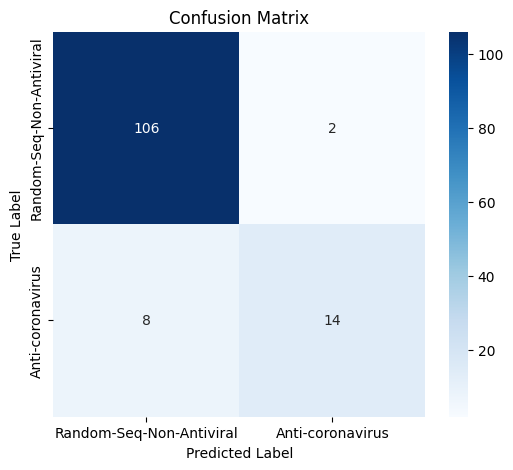


🔹 Classification Report:

                          precision    recall  f1-score   support

Random-Seq-Non-Antiviral       0.93      0.98      0.95       108
        Anti-coronavirus       0.88      0.64      0.74        22

                accuracy                           0.92       130
               macro avg       0.90      0.81      0.85       130
            weighted avg       0.92      0.92      0.92       130



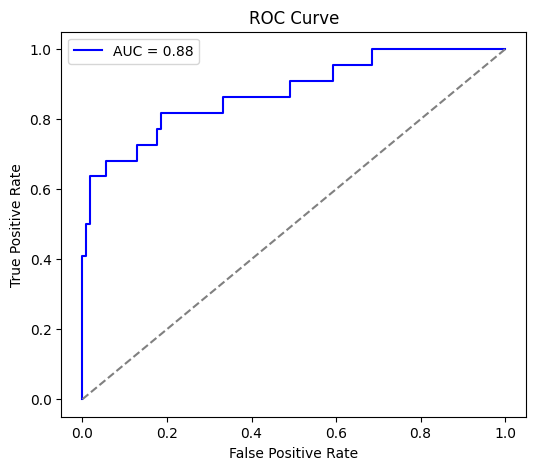

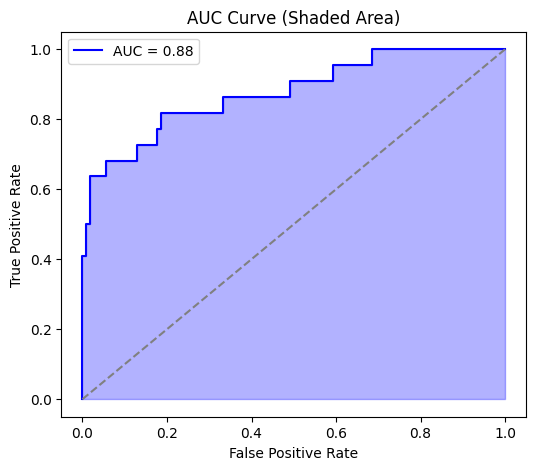

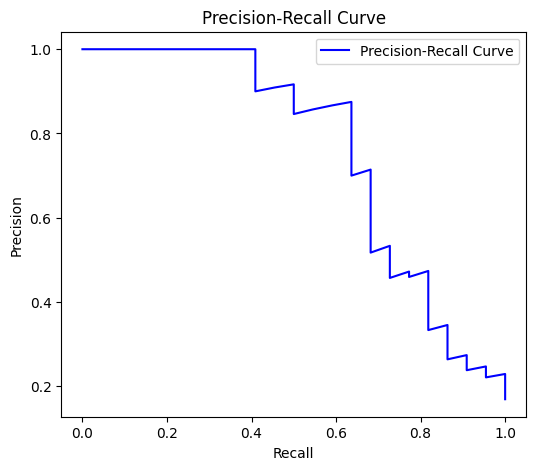

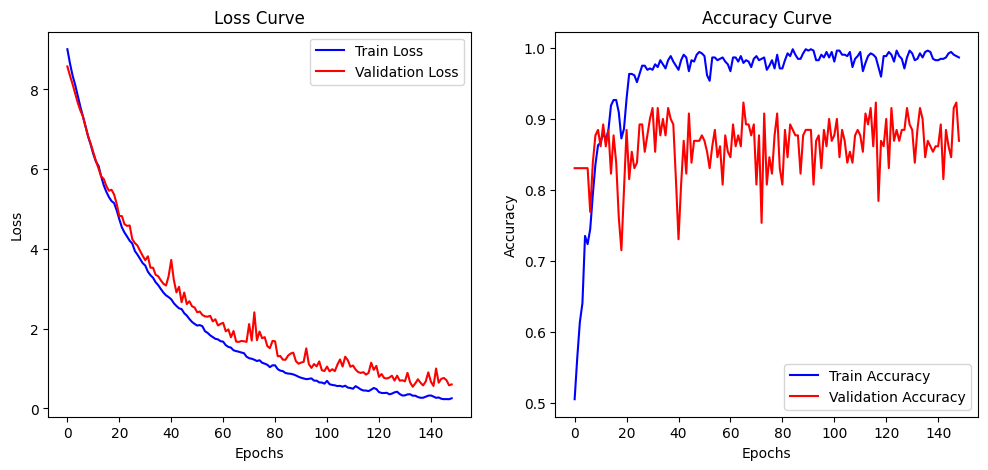

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 

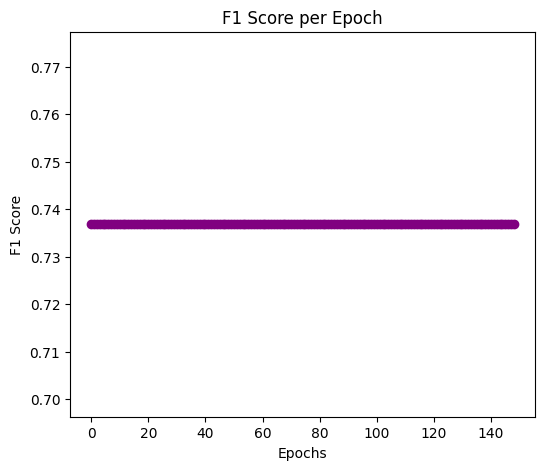

Cohen’s Kappa Score: 0.69
Matthews Correlation Coefficient (MCC): 0.71


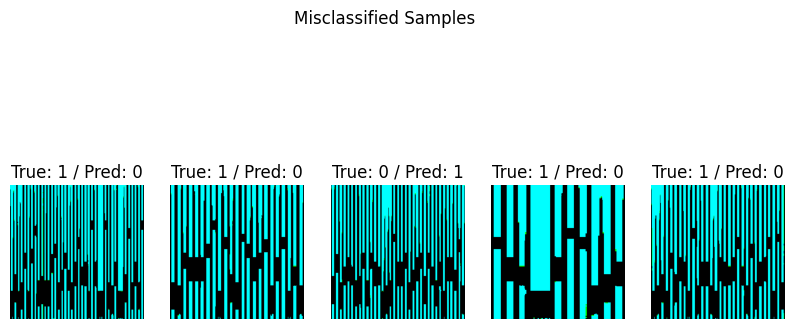


🔟 Performance Metrics Summary Table (For Research Paper)

   Metric  Score
 Accuracy 0.9231
Precision 0.8750
   Recall 0.6364
 F1-score 0.7368
      AUC 0.8763
      MCC 0.7052
   G-mean 0.7903


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, f1_score, cohen_kappa_score, matthews_corrcoef,
    accuracy_score, precision_score, recall_score
)
import pandas as pd
import random

# ➤ 1. Get predictions
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int)

# ➤ 2. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"],
            yticklabels=["Random-Seq-Non-Antiviral", "Anti-coronavirus"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ➤ 3. Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Random-Seq-Non-Antiviral", "Anti-coronavirus"]))

# ➤ 4. ROC Curve & AUC Score
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# ➤ 4b. AUC Curve with Shaded Area (Separate Plot)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.fill_between(fpr, tpr, alpha=0.3, color='blue')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('AUC Curve (Shaded Area)')
plt.legend()
plt.show()

# ➤ 5. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

# ➤ 6. Training Loss & Accuracy Curves
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# ➤ 7. F1 Score per Epoch (optional approximation)
f1_scores = [f1_score(y_test, (model.predict(X_test) > 0.5).astype(int)) for _ in range(len(history.history['loss']))]
plt.figure(figsize=(6,5))
plt.plot(f1_scores, color='purple', marker='o')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score per Epoch')
plt.show()

# ➤ 8. Cohen’s Kappa Score
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Cohen’s Kappa Score: {kappa_score:.2f}")

# ➤ 9. Matthews Correlation Coefficient
mcc = matthews_corrcoef(y_test, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.2f}")

# ➤ 10. Error Analysis (Misclassified Samples)
misclassified_idx = np.where(y_pred.flatten() != y_test.flatten())[0]
if len(misclassified_idx) > 5:
    misclassified_idx = random.sample(list(misclassified_idx), 5)

plt.figure(figsize=(10,5))
for i, idx in enumerate(misclassified_idx):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].astype("uint8"))
    plt.title(f"True: {y_test[idx]} / Pred: {y_pred[idx][0]}")
    plt.axis("off")
plt.suptitle("Misclassified Samples")
plt.show()

# ➤ 11. Performance Metrics Summary Table (for Paper)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
accuracy = accuracy_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
recall_val = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
sensitivity = recall_val
specificity = tn / (tn + fp)
gmean = np.sqrt(sensitivity * specificity)

performance_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "AUC", "MCC", "G-mean"],
    "Score": [accuracy, precision_val, recall_val, f1, roc_auc, mcc, gmean]
})

print("\n🔟 Performance Metrics Summary Table (For Research Paper)\n")
print(performance_df.round(4).to_string(index=False))
